In [16]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization

import sklearn.metrics
import statistics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

file_path = 'preprocessed_combined_data_weekday_and_national_holiday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0


In [17]:
scaler = StandardScaler()
linear_regressor = LinearRegression() 

x = df.drop('kW',axis = 1) 
y = df.kW

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
Fit = scaler.fit(x_train)

x_train_scaled = Fit.transform(x_train)
x_test_scaled = Fit.transform(x_test)

linear_regressor.fit(x_train_scaled, y_train)
y_predict_train = linear_regressor.predict(x_train_scaled)
y_predict_test = linear_regressor.predict(x_test_scaled)


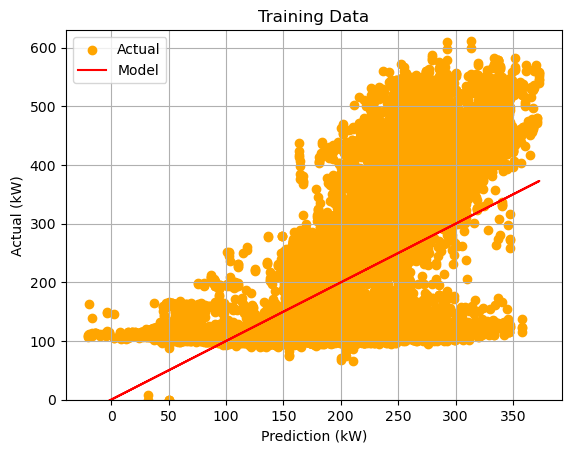

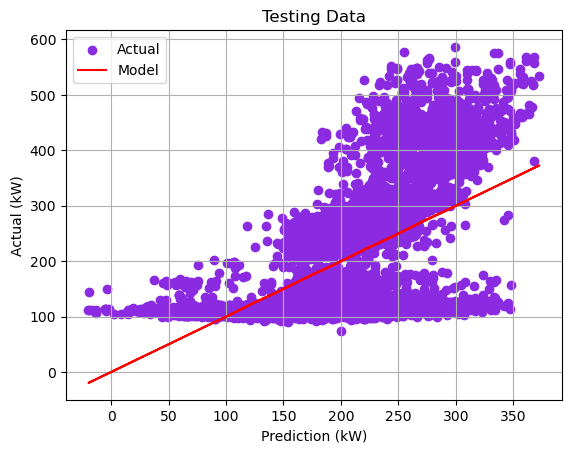

In [18]:
# Plot predicted train vs actual training data
fig,ax = plt.subplots()
ax.scatter(y_predict_train,y_train, c='orange', label='Actual')
ax.plot(y_predict_train, y_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()
ax.set_ylim([0, 630])

# Plot predicted test vs actual test data
fig,ax = plt.subplots()
ax.scatter(y_predict_test, y_test, c='blueviolet', label='Actual')
ax.plot(y_predict_test, y_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
ax.legend()
ax.grid()

In [19]:
# Error Evaluation 
# Training error 

print("Train Data")
print("R^2:", r2_score(y_train, y_predict_train))
print("MSE:", mean_squared_error(y_train, y_predict_train))
print("Root MSE:", np.sqrt(mean_squared_error(y_train, y_predict_train)))
print("MAE:", mean_absolute_error(y_train, y_predict_train))
print("MAPE: %", mean_absolute_percentage_error(y_train ,y_predict_train))

print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y_test, y_predict_test))
print("MSE:", mean_squared_error(y_test, y_predict_test))
print("Root MSE:", np.sqrt(mean_squared_error(y_test, y_predict_test)))
print("MAE:", mean_absolute_error(y_test, y_predict_test))
print("MAPE: %", mean_absolute_percentage_error(y_test, y_predict_test))


Train Data
R^2: 0.3680427254197205
MSE: 9439.180109641537
Root MSE: 97.15544302632527
MAE: 79.67507839366087
MAPE: % 29521282465285.453
 
Test Data
R^2: 0.38862085767157617
MSE: 9189.702592066484
Root MSE: 95.86293648781307
MAE: 78.26564749036811
MAPE: % 0.47389919320543217


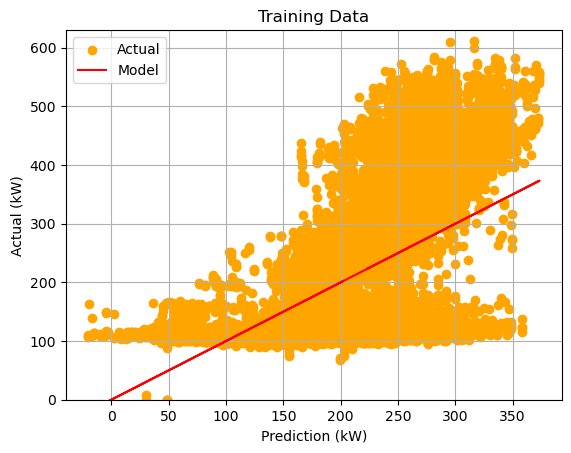

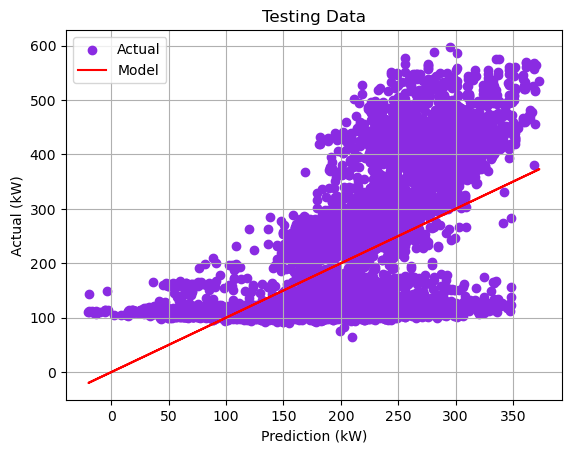

In [20]:
x2 = df.drop('kW',axis = 1)
y2 = df.kW

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.30, random_state=42)
Fit = scaler.fit(x2_train)

x2_train_scaled = Fit.transform(x2_train)
x2_test_scaled = Fit.transform(x2_test)

linear_regressor.fit(x2_train_scaled, y2_train)
y2_predict_train = linear_regressor.predict(x2_train_scaled)
y2_predict_test = linear_regressor.predict(x2_test_scaled)

# Plot predicted train vs actual training data
fig,ax = plt.subplots()
ax.scatter(y2_predict_train,y2_train, c='orange', label='Actual')
ax.plot(y2_predict_train, y2_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()
ax.set_ylim([0, 630])

# Plot predicted test vs actual test data
fig,ax = plt.subplots()
ax.scatter(y2_predict_test, y2_test, c='blueviolet', label='Actual')
ax.plot(y2_predict_test, y2_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
ax.legend()
ax.grid()

In [21]:
# Error Evaluation 
# Training error 

print("Train Data")
print("R^2:", r2_score(y2_train, y2_predict_train))
print("MSE:", mean_squared_error(y2_train, y2_predict_train))
print("Root MSE:", np.sqrt(mean_squared_error(y2_train, y2_predict_train)))
print("MAE:", mean_absolute_error(y2_train, y2_predict_train))
print("MAPE: %", mean_absolute_percentage_error(y2_train ,y2_predict_train))

print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y2_test, y2_predict_test))
print("MSE:", mean_squared_error(y2_test, y2_predict_test))
print("Root MSE:", np.sqrt(mean_squared_error(y2_test, y2_predict_test)))
print("MAE:", mean_absolute_error(y2_test, y2_predict_test))
print("MAPE: %", mean_absolute_percentage_error(y2_test, y2_predict_test))

Train Data
R^2: 0.3693452703739911
MSE: 9455.634539448434
Root MSE: 97.24008710119729
MAE: 79.7507614454476
MAPE: % 32355940446497.273
 
Test Data
R^2: 0.37887795616069053
MSE: 9234.10839392689
Root MSE: 96.09426826781548
MAE: 78.67910282734107
MAPE: % 0.47954629811383664


Create a summer dataset from July, July-August and June-July-August to test

In [22]:
df.index = pd.to_datetime(df.index)

display(df)

mask = (df.index.month >= 7) & (df.index.month <= 8)  # July- August / 2 months
mask2 = (df.index.month >= 7) & (df.index.month < 8)  # July / 1 month
mask3 = (df.index.month >= 6) & (df.index.month <= 8) # June - July - August / 3 months

df_july_august = df[mask]
df_july = df[mask2]
df_june_august = df[mask3]

display(df_july)
display(df_july_august)
display(df_june_august)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0


,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-07-01 00:00:00,126.000,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 00:15:00,142.200,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 00:30:00,121.500,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 00:45:00,120.152,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 01:00:00,119.248,0,1,29.88,37.0,88,0.0,0.322917,40.0,103.0,39.0,90.0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-31 22:45:00,115.200,1,1,30.07,64.0,82,0.0,0.260417,68.0,78.0,64.0,89.0,0,0,0,0,0,0,1,0
2022-07-31 23:00:00,112.948,1,1,30.06,65.0,80,0.0,0.239583,70.0,83.0,64.0,88.0,0,0,0,0,0,0,1,0
2022-07-31 23:15:00,108.000,1,1,30.06,65.0,80,0.0,0.239583,70.0,83.0,64.0,88.0,0,0,0,0,0,0,1,0


,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-07-01 00:00:00,126.000,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 00:15:00,142.200,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 00:30:00,121.500,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 00:45:00,120.152,0,1,29.88,35.0,89,0.0,0.333333,41.0,102.0,39.0,91.0,0,0,0,0,1,0,0,0
2022-07-01 01:00:00,119.248,0,1,29.88,37.0,88,0.0,0.322917,40.0,103.0,39.0,90.0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-31 22:45:00,111.152,0,1,29.85,37.0,91,0.0,0.354167,42.0,102.0,45.0,92.0,0,0,1,0,0,0,0,0
2022-08-31 23:00:00,109.348,0,1,29.85,37.0,92,0.0,0.364583,41.0,105.0,43.0,92.0,0,0,1,0,0,0,0,0
2022-08-31 23:15:00,113.400,0,1,29.85,37.0,92,0.0,0.364583,41.0,105.0,43.0,92.0,0,0,1,0,0,0,0,0


,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-06-01 00:00:00,109.800,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0,0
2022-06-01 00:15:00,110.248,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0,0
2022-06-01 00:30:00,110.248,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0,0
2022-06-01 00:45:00,109.348,1,1,29.93,28.0,74,0.0,0.177083,25.0,81.0,24.0,69.0,0,0,1,0,0,0,0,0
2022-06-01 01:00:00,110.700,1,1,29.95,27.0,72,0.0,0.156250,25.0,84.0,19.0,67.0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-31 22:45:00,111.152,0,1,29.85,37.0,91,0.0,0.354167,42.0,102.0,45.0,92.0,0,0,1,0,0,0,0,0
2022-08-31 23:00:00,109.348,0,1,29.85,37.0,92,0.0,0.364583,41.0,105.0,43.0,92.0,0,0,1,0,0,0,0,0
2022-08-31 23:15:00,113.400,0,1,29.85,37.0,92,0.0,0.364583,41.0,105.0,43.0,92.0,0,0,1,0,0,0,0,0


Linear Regression for timeframes July, July - August, June - July - August
 
Train Data
R^2: 0.43713904102218326
MSE: 15379.84404892499
Root MSE: 124.0154992286246
MAE: 104.96281599757116
MAPE: % 0.6049312572461503
 
Test Data
R^2: 0.3963095974370433
MSE: 16497.489738448832
Root MSE: 128.4425542351476
MAE: 108.93024842154975
MAPE: % 0.6276117094252337
 
Train Data
R^2: 0.4107161520412509
MSE: 15300.762905670894
Root MSE: 123.69625259348358
MAE: 105.0941518126424
MAPE: % 0.6084367513668412
 
Test Data
R^2: 0.40433921812245766
MSE: 15707.496466936016
Root MSE: 125.32955145110836
MAE: 106.44369088575002
MAPE: % 0.6214814698365981
 
Train Data
R^2: 0.3988719739511104
MSE: 15478.663779276492
Root MSE: 124.4132781469747
MAE: 105.83744618550853
MAPE: % 0.6106672576848858
 
Test Data
R^2: 0.3583933761426362
MSE: 15869.522417427923
Root MSE: 125.97429268476931
MAE: 107.28506154548582
MAPE: % 0.6365464591531378


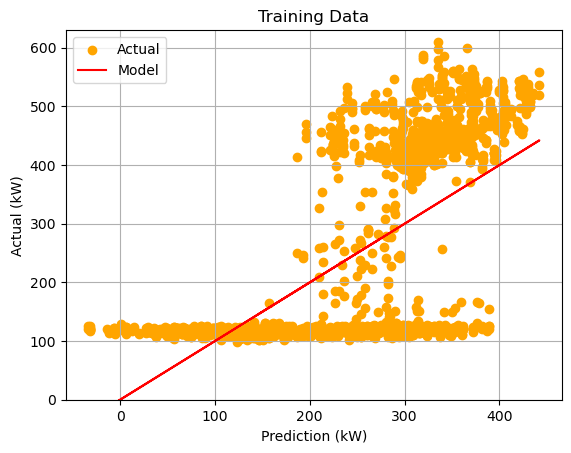

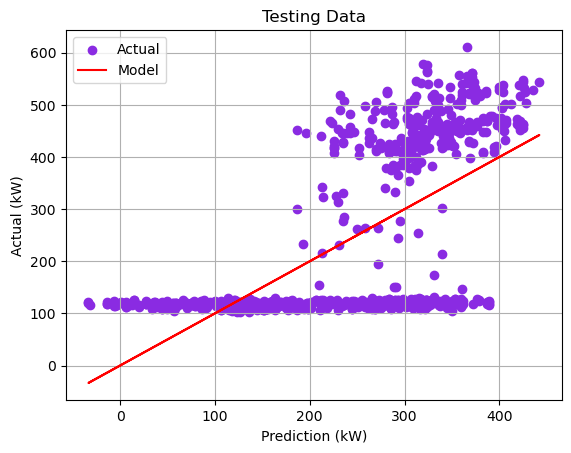

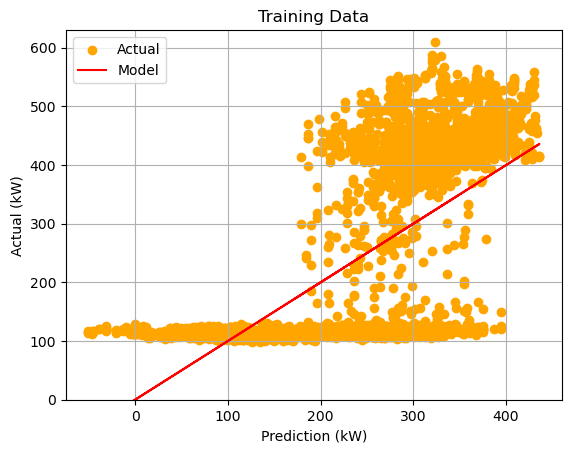

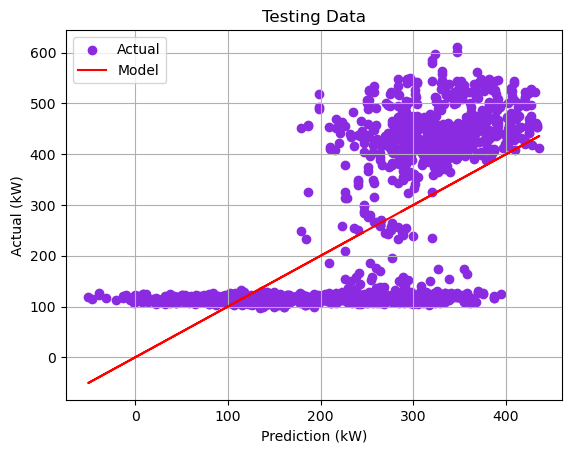

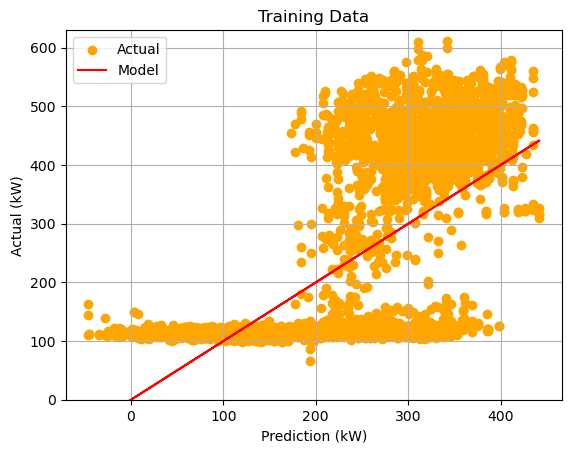

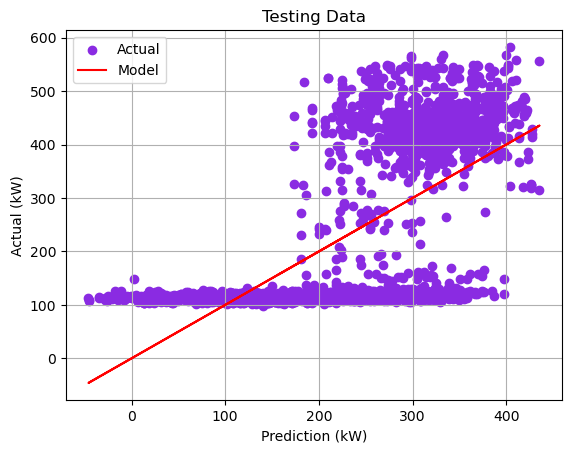

In [23]:
datasets = [df_july, df_july_august, df_june_august]

print("Linear Regression for timeframes July, July - August, June - July - August")

for data in datasets:

    x3 = data.drop('kW',axis = 1)
    y3 = data.kW

    x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.30, random_state=42)
    Fit = scaler.fit(x3_train)

    x3_train_scaled = Fit.transform(x3_train)
    x3_test_scaled = Fit.transform(x3_test)

    linear_regressor.fit(x3_train_scaled, y3_train)
    y3_predict_train = linear_regressor.predict(x3_train_scaled)
    y3_predict_test = linear_regressor.predict(x3_test_scaled)

    # Plot predicted train vs actual training data
    fig,ax = plt.subplots()
    ax.scatter(y3_predict_train,y3_train, c='orange', label='Actual')
    ax.plot(y3_predict_train, y3_predict_train, c="red", label='Model')
    ax.set_xlabel('Prediction (kW)')
    ax.set_ylabel('Actual (kW)')
    ax.set_title('Training Data')
    ax.legend()
    ax.grid()
    ax.set_ylim([0, 630])

    # Plot predicted test vs actual test data
    fig,ax = plt.subplots()
    ax.scatter(y3_predict_test, y3_test, c='blueviolet', label='Actual')
    ax.plot(y3_predict_test, y3_predict_test, c="red", label='Model')
    ax.set_xlabel('Prediction (kW)')
    ax.set_ylabel('Actual (kW)')
    ax.set_title('Testing Data')
    ax.legend()
    ax.grid()

    # Error Evaluation 
    # Training error
     
    print(" ")

    print("Train Data")
    print("R^2:", r2_score(y3_train, y3_predict_train))
    print("MSE:", mean_squared_error(y3_train, y3_predict_train))
    print("Root MSE:", np.sqrt(mean_squared_error(y3_train, y3_predict_train)))
    print("MAE:", mean_absolute_error(y3_train, y3_predict_train))
    print("MAPE: %", mean_absolute_percentage_error(y3_train ,y3_predict_train))

    print(" ")

    # Test Error
    print("Test Data")
    print("R^2:", r2_score(y3_test, y3_predict_test))
    print("MSE:", mean_squared_error(y3_test, y3_predict_test))
    print("Root MSE:", np.sqrt(mean_squared_error(y3_test, y3_predict_test)))
    print("MAE:", mean_absolute_error(y3_test, y3_predict_test))
    print("MAPE: %", mean_absolute_percentage_error(y3_test, y3_predict_test))
